In [ ]:
# pip install ema_workbench

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.7/28.7 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.4/124.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 18.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print(np.__version__)
print(np.__file__)
print(hasattr(np, "bool"))

data = pd.read_excel(
    "SCI_2025_reshaped_rows_africaR5.xlsx",
    sheet_name="Data"
)

# Remove units row
data = data.iloc[1:].reset_index(drop=True)

# Convert all columns except Model and Scenario
for col in data.columns[2:]:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Remove rows with missing values
data = data.dropna()

print(data.shape)
print(data.dtypes)

2.0.2
/usr/local/lib/python3.12/dist-packages/numpy/__init__.py
True
(763, 15)
Model                      object
Scenario                   object
Emissions|CO2             float64
Final Energy              float64
Primary Energy            float64
Primary Energy|Coal       float64
Primary Energy|Oil        float64
Primary Energy|Gas        float64
Primary Energy|Biomass    float64
Primary Energy|Nuclear    float64
Primary Energy|Solar      float64
Primary Energy|Wind       float64
Population                float64
Consumption               float64
GDP|PPP                   float64
dtype: object


In [ ]:
data

,Model,Scenario,Emissions|CO2,Final Energy,Primary Energy,Primary Energy|Coal,Primary Energy|Oil,Primary Energy|Gas,Primary Energy|Biomass,Primary Energy|Nuclear,Primary Energy|Solar,Primary Energy|Wind,Population,Consumption,GDP|PPP
30,AIM/CGE 2.1,COMMIT-Bridge,484.243300,69.482400,127.308300,1.081000,39.868000,44.274500,35.568100,0.745400,0.935100,0.730400,2866.048100,18203.687391,62793.363430
31,AIM/CGE 2.1,COMMIT-Current-Policies,10104.355300,115.300100,170.443400,31.303600,51.716200,54.504300,29.380200,0.310100,0.318000,0.347600,2866.048100,20902.432877,68955.882426
42,AIM/CGE V2.2,ENGAGE-INDCi2030-1000f,-640.066400,82.514300,113.481400,1.662000,17.018300,9.646200,31.683500,0.733600,27.099900,22.068600,3066.028300,82819.194300,228581.114300
43,AIM/CGE V2.2,ENGAGE-INDCi2030-1200,20.002100,83.374500,113.527700,2.009600,20.427900,11.789800,28.053400,0.722700,25.846500,21.238200,3066.028300,83544.557100,229555.901800
44,AIM/CGE V2.2,ENGAGE-INDCi2030-1200f,-568.917800,82.155600,115.446700,2.439400,17.411500,11.881500,31.320700,0.732300,26.514300,21.560700,3066.028300,82816.205600,228435.399300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1533,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,-1213.658872,69.817854,164.017452,0.370591,31.527821,34.341346,45.495861,0.007509,20.211347,29.819351,2989.281279,51673.228959,149206.505492
1534,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1600,818.406813,84.216179,193.325452,1.001367,55.873002,43.458749,45.495287,0.005344,18.890172,26.362235,2989.281279,54492.625563,157603.483348
1535,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,-2545.867781,59.732099,137.755241,0.187609,15.753675,21.340087,45.495861,0.014737,21.044236,31.660949,2989.281279,47886.483860,137933.591295
1536,WITCH-GLOBIOM 4.4,CD-LINKS-NPi,14813.945615,110.815609,266.727624,16.984765,119.002030,89.249980,17.162595,0.003245,8.421035,13.668876,2989.281279,59699.530349,169939.100302


In [ ]:
data["Consumption_per_capita"] = (
    data["Consumption"] / data["Population"]
)

data["Final_Energy_per_capita"] = (
    data["Final Energy"] / data["Population"]
)

# Check
print(data[[
    "Consumption",
    "Final Energy",
    "Population",
    "Consumption_per_capita",
    "Final_Energy_per_capita"
]].head())

     Consumption  Final Energy  Population  Consumption_per_capita  \
30  18203.687391       69.4824   2866.0481                6.351494   
31  20902.432877      115.3001   2866.0481                7.293120   
42  82819.194300       82.5143   3066.0283               27.011882   
43  83544.557100       83.3745   3066.0283               27.248462   
44  82816.205600       82.1556   3066.0283               27.010907   

    Final_Energy_per_capita  
30                 0.024243  
31                 0.040230  
42                 0.026912  
43                 0.027193  
44                 0.026795  


In [ ]:
data

,Model,Scenario,Emissions|CO2,Final Energy,Primary Energy,Primary Energy|Coal,Primary Energy|Oil,Primary Energy|Gas,Primary Energy|Biomass,Primary Energy|Nuclear,Primary Energy|Solar,Primary Energy|Wind,Population,Consumption,GDP|PPP,Consumption_per_capita,Final_Energy_per_capita
30,AIM/CGE 2.1,COMMIT-Bridge,484.243300,69.482400,127.308300,1.081000,39.868000,44.274500,35.568100,0.745400,0.935100,0.730400,2866.048100,18203.687391,62793.363430,6.351494,0.024243
31,AIM/CGE 2.1,COMMIT-Current-Policies,10104.355300,115.300100,170.443400,31.303600,51.716200,54.504300,29.380200,0.310100,0.318000,0.347600,2866.048100,20902.432877,68955.882426,7.293120,0.040230
42,AIM/CGE V2.2,ENGAGE-INDCi2030-1000f,-640.066400,82.514300,113.481400,1.662000,17.018300,9.646200,31.683500,0.733600,27.099900,22.068600,3066.028300,82819.194300,228581.114300,27.011882,0.026912
43,AIM/CGE V2.2,ENGAGE-INDCi2030-1200,20.002100,83.374500,113.527700,2.009600,20.427900,11.789800,28.053400,0.722700,25.846500,21.238200,3066.028300,83544.557100,229555.901800,27.248462,0.027193
44,AIM/CGE V2.2,ENGAGE-INDCi2030-1200f,-568.917800,82.155600,115.446700,2.439400,17.411500,11.881500,31.320700,0.732300,26.514300,21.560700,3066.028300,82816.205600,228435.399300,27.010907,0.026795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1533,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,-1213.658872,69.817854,164.017452,0.370591,31.527821,34.341346,45.495861,0.007509,20.211347,29.819351,2989.281279,51673.228959,149206.505492,17.286172,0.023356
1534,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1600,818.406813,84.216179,193.325452,1.001367,55.873002,43.458749,45.495287,0.005344,18.890172,26.362235,2989.281279,54492.625563,157603.483348,18.229340,0.028173
1535,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,-2545.867781,59.732099,137.755241,0.187609,15.753675,21.340087,45.495861,0.014737,21.044236,31.660949,2989.281279,47886.483860,137933.591295,16.019397,0.019982
1536,WITCH-GLOBIOM 4.4,CD-LINKS-NPi,14813.945615,110.815609,266.727624,16.984765,119.002030,89.249980,17.162595,0.003245,8.421035,13.668876,2989.281279,59699.530349,169939.100302,19.971199,0.037071


In [ ]:
data.describe()

,Emissions|CO2,Final Energy,Primary Energy,Primary Energy|Coal,Primary Energy|Oil,Primary Energy|Gas,Primary Energy|Biomass,Primary Energy|Nuclear,Primary Energy|Solar,Primary Energy|Wind,Population,Consumption,GDP|PPP,Consumption_per_capita,Final_Energy_per_capita
count,763.000000,763.000000,763.000000,7.630000e+02,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000
mean,2808.354541,165.914104,233.530035,1.131130e+01,24.547184,40.234814,27.297251,4.988129,77.587636,42.515590,3066.107376,74343.860493,168041.884395,24.501126,0.054486
std,5611.524906,54.092721,62.749938,2.797913e+01,23.798001,26.348405,14.003067,8.839187,45.660630,23.221205,348.988732,37929.915797,35964.954178,12.419057,0.018395
min,-5709.398217,51.653223,59.197167,-3.469447e-18,0.000000,0.000003,0.018858,0.000000,0.318000,0.347600,2098.103000,0.000000,43362.155674,0.000000,0.013864
25%,-413.785220,111.851824,192.216818,4.575000e-02,8.005010,17.084108,17.988200,0.000000,30.989675,25.633154,3060.261200,43672.678800,155948.524735,14.306533,0.037964
50%,909.474452,176.465932,237.257728,9.118010e-01,17.662100,40.693745,26.439547,0.224714,84.123400,39.452108,3087.570000,70759.721939,161725.479000,22.438951,0.056860
75%,3778.480000,211.725410,276.171646,5.981336e+00,35.028680,57.376256,38.093220,5.625638,112.790229,55.318644,3176.039094,103931.159239,184198.853003,33.659140,0.069105
max,33286.834068,294.773164,434.727700,1.893463e+02,132.516287,168.979412,70.450764,50.719059,265.973856,113.478943,4619.555000,137187.352048,330977.384838,56.504341,0.136756


In [ ]:
outcome_interest = 2
factors = list(range(3,16))
#factors = [6, 7, 8, 9]

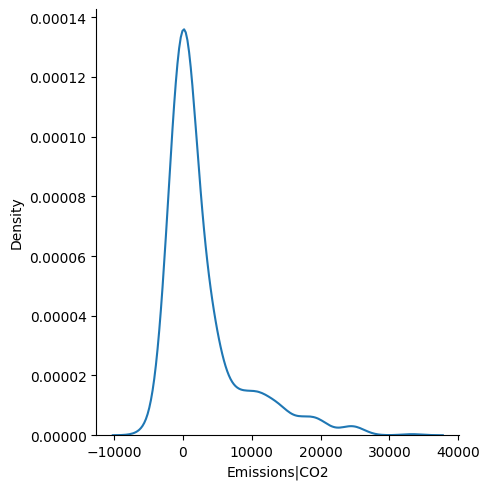

In [ ]:

import seaborn as sns
sns.displot(data.iloc[:, outcome_interest],kind='kde')

In [ ]:
#define threshold for outcome of interest

threshold_interest = 0

x = data.iloc[:, factors]
y = data.iloc[:, outcome_interest].values < threshold_interest

print(f"There are {sum(y)} cases of interest, out of {len(y)} scenarios")

There are 266 cases of interest, out of 763 scenarios


In [ ]:
# from ema_workbench.analysis import cart

# cart_alg = cart.CART(x, y)
# cart_alg.build_tree()

# fig = cart_alg.show_tree()
# fig.set_size_inches((18, 12))
# plt.show()

In [ ]:
#PRIM analysis
from ema_workbench.analysis import prim
from ema_workbench.util import ema_logging

#ema_logging.log_to_stderr(ema_logging.INFO);

In [ ]:
prim_alg = prim.Prim(x, y)
box1 = prim_alg.find_box()

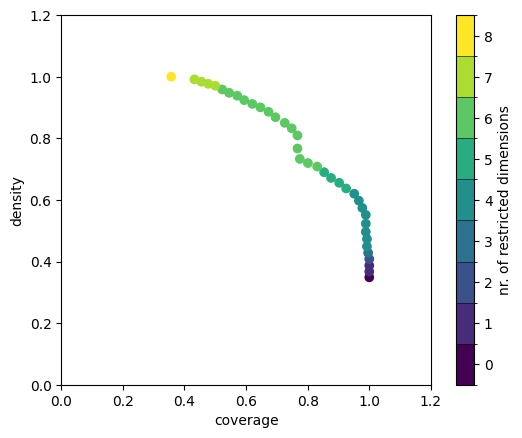

In [ ]:
#Visualize first box tradeoff
box1.show_tradeoff()
plt.show()

In [ ]:
box1.inspect_tradeoff()

alt.VConcatChart(...)

In [ ]:
box1.inspect(style='data')

[(coverage     0.357143
  density      1.000000
  id          36.000000
  k           95.000000
  mass         0.124509
  mean         1.000000
  n           95.000000
  res_dim      8.000000
  Name: 36, dtype: float64,
                                box 36                                   
                                   min            max  qp value  qp value
  Primary Energy|Coal    -3.469447e-18       2.663500       NaN  1.000000
  Primary Energy|Oil      0.000000e+00      15.501400       NaN  0.001060
  Primary Energy|Gas      4.890000e+00      31.176692  0.377431  0.000009
  Primary Energy|Biomass  2.246980e+01      70.450764  1.000000       NaN
  Primary Energy|Nuclear  3.500000e-04      50.719059  0.439325       NaN
  Primary Energy|Solar    3.180000e-01     159.384571       NaN  1.000000
  Population              2.098103e+03    3306.216025       NaN  0.024090
  Consumption             0.000000e+00  134415.598624       NaN  1.000000)]

In [ ]:
emissions_thr = data["Emissions|CO2"].median()
energy_thr = data["Final_Energy_per_capita"].median()

print(emissions_thr)
print(energy_thr)

909.4744519844236
0.05685958920497069


In [ ]:
def classify(row):

    if row["Emissions|CO2"] <= emissions_thr:
        if row["Final_Energy_per_capita"] >= energy_thr:
            return "Sustainable Development"

        else:
            return "Energy Poverty Transition"

    else:
        if row["Final_Energy_per_capita"] >= energy_thr:
            return "Carbon Intensive Growth"

        else:
            return "High Carbon Poverty"

data["quadrant"] = data.apply(classify, axis=1)

In [ ]:
data["quadrant"].value_counts()

,count
quadrant,
Energy Poverty Transition,212
Carbon Intensive Growth,212
Sustainable Development,170
High Carbon Poverty,169


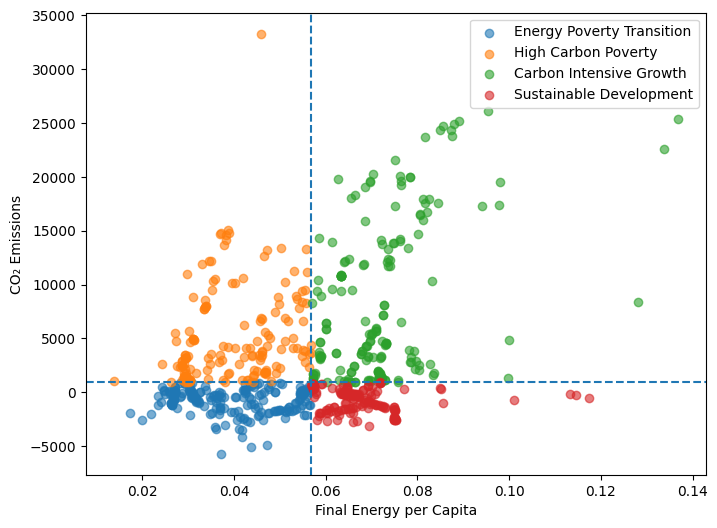

In [ ]:
plt.figure(figsize=(8,6))

for q in data["quadrant"].unique():

    subset = data[data["quadrant"] == q]

    plt.scatter(
        subset["Final_Energy_per_capita"],
        subset["Emissions|CO2"],
        alpha=0.6,
        label=q
    )

plt.axhline(emissions_thr, ls="--")
plt.axvline(energy_thr, ls="--")

plt.xlabel("Final Energy per Capita")
plt.ylabel("CO₂ Emissions")
plt.legend()
plt.show()

In [ ]:
y_sd = (
    data["quadrant"] == "Sustainable Development"
).astype(int)

prim_sd = prim.Prim(x, y_sd.values)
box_sd = prim_sd.find_box()

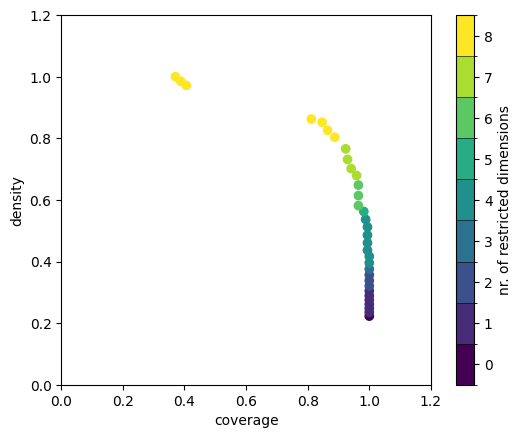

In [ ]:
box_sd.show_tradeoff()
plt.show()

In [ ]:
box_sd.inspect(style='data')

[(coverage     0.370588
  density      1.000000
  id          32.000000
  k           63.000000
  mass         0.082569
  mean         1.000000
  n           63.000000
  res_dim      8.000000
  Name: 32, dtype: float64,
                                box 32                               \
                                   min            max      qp value   
  Final Energy            1.928217e+02     294.773164  1.742546e-17   
  Primary Energy|Coal    -3.469447e-18      30.602503           NaN   
  Primary Energy|Oil      0.000000e+00      19.622452           NaN   
  Primary Energy|Biomass  5.589349e+00      70.450764  1.000000e+00   
  Primary Energy|Solar    2.582629e+01     265.973856  1.000000e+00   
  Population              2.098103e+03    3087.569973           NaN   
  Consumption             0.000000e+00  134707.389950           NaN   
  GDP|PPP                 1.238241e+05  330977.384838  1.000000e+00   
  
                                        
                          

In [ ]:
y_hcp = (
    data["quadrant"] == "High Carbon Poverty"
).astype(int)

prim_hcp = prim.Prim(x, y_hcp.values)
box_hcp = prim_hcp.find_box()

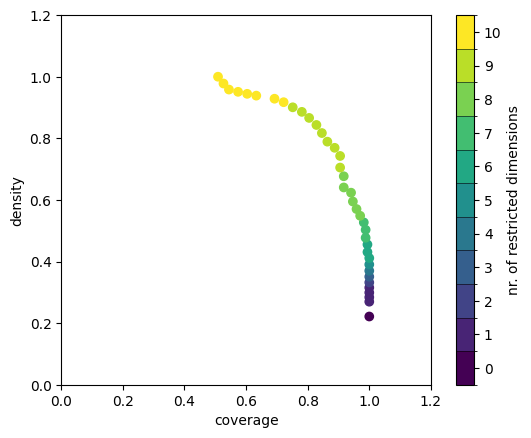

In [ ]:
box_hcp.show_tradeoff()
plt.show()

In [ ]:
box_hcp.inspect(style='data')

[(coverage     0.508876
  density      1.000000
  id          37.000000
  k           86.000000
  mass         0.112713
  mean         1.000000
  n           86.000000
  res_dim     10.000000
  Name: 37, dtype: float64,
                                box 37                                   
                                   min            max  qp value  qp value
  Final Energy               90.719808     174.198733  0.003440  0.000005
  Primary Energy|Coal         0.047050      39.284928  1.000000  1.000000
  Primary Energy|Oil         21.260809     132.516287  0.000011       NaN
  Primary Energy|Gas         12.359174     168.979412  1.000000       NaN
  Primary Energy|Biomass      0.018858      49.692191       NaN  0.382547
  Primary Energy|Nuclear      0.000000      10.003605       NaN  1.000000
  Primary Energy|Solar        0.318000     117.028603       NaN  1.000000
  Primary Energy|Wind         0.347600      42.967252       NaN  0.000255
  GDP|PPP                 43362.155674  

In [ ]:
y_cig = (
    data["quadrant"] == "Carbon Intensive Growth"
).astype(int)

prim_cig = prim.Prim(x, y_cig.values)
box_cig = prim_cig.find_box()

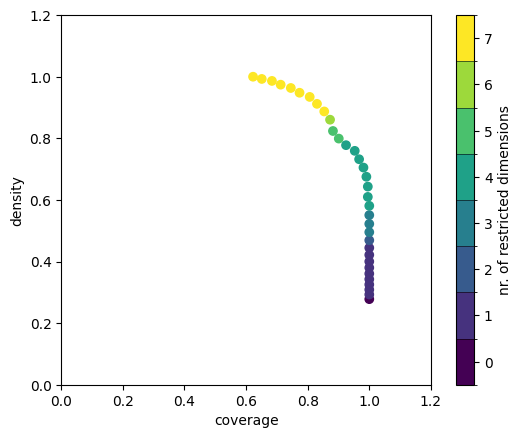

In [ ]:
box_cig.show_tradeoff()
plt.show()

In [ ]:
box_cig.inspect(style='data')

[(coverage      0.622642
  density       1.000000
  id           33.000000
  k           132.000000
  mass          0.173001
  mean          1.000000
  n           132.000000
  res_dim       7.000000
  Name: 33, dtype: float64,
                               box 33                                     
                                  min          max      qp value  qp value
  Final Energy             181.467857   294.773164  1.235015e-24       NaN
  Primary Energy|Oil         9.918513   132.516287  4.738264e-03       NaN
  Primary Energy|Gas        38.287374   100.869580  4.241457e-03  0.058495
  Primary Energy|Biomass     0.018858    41.562058           NaN  0.369269
  Primary Energy|Solar       0.318000   118.492902           NaN  0.388198
  Primary Energy|Wind        0.347600    85.700850           NaN  1.000000
  Population              2098.103000  3372.122461           NaN  0.056128)]

In [ ]:
y_ept = (
    (data["Emissions|CO2"] <= emissions_thr) &
    (data["Final_Energy_per_capita"] < energy_thr)
).astype(int)

prim_ept = prim.Prim(x, y_ept.values)
box_ept = prim_ept.find_box()

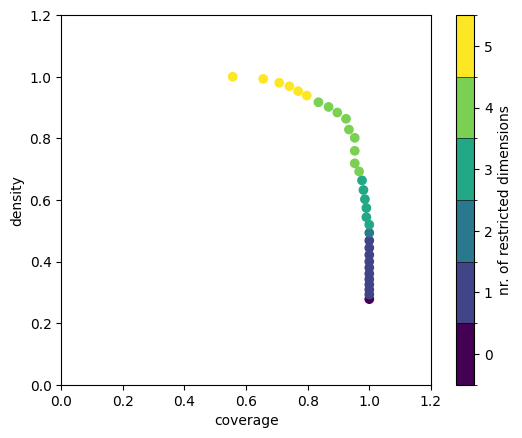

In [ ]:
box_ept.show_tradeoff()
plt.show()

In [ ]:
box_ept.inspect(style='data')

[(coverage      0.556604
  density       1.000000
  id           32.000000
  k           118.000000
  mass          0.154653
  mean          1.000000
  n           118.000000
  res_dim       5.000000
  Name: 32, dtype: float64,
                               box 32                                       
                                  min            max  qp value      qp value
  Final Energy              51.653223     172.619700       NaN  8.429407e-26
  Primary Energy|Oil         0.000000      24.314996       NaN  2.794549e-20
  Primary Energy|Biomass    21.700489      47.536068  0.004680  1.457094e-03
  Population              2180.205700    3195.207076  0.162769  1.830862e-02
  Consumption                0.000000  123576.751645       NaN  1.000000e+00)]